# Chapter 15 — Eigendecomposition and SVD Applications

## Learning Objectives

This notebook covers PCA through eigendecomposition/SVD, low-rank approximation, denoising, and LDA intuition.

## Theoretical Explanation

PCA finds orthogonal directions of maximal variance. It can be computed from the eigendecomposition of the covariance matrix or from SVD of a centered data matrix. Low-rank SVD approximations reconstruct data using only the strongest components. This supports compression and denoising.

LDA is related but supervised: it seeks directions that separate classes instead of merely maximizing variance.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import norm, matrix_rank

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. PCA via SVD

first five variance ratios: [0.362 0.192 0.111 0.071 0.066]


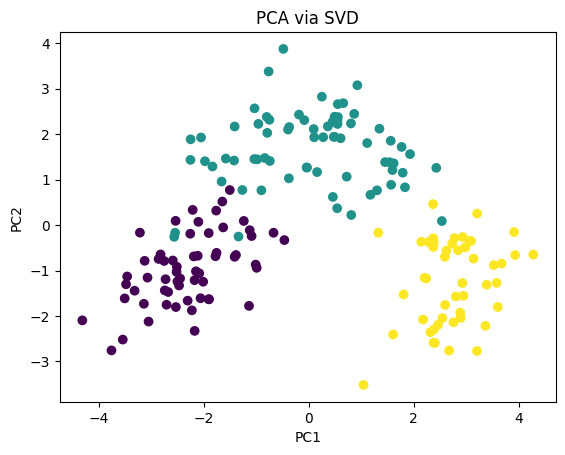

In [2]:
from sklearn.datasets import load_wine
wine = load_wine()
X = wine.data
Xc = (X - X.mean(axis=0)) / X.std(axis=0)
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
scores = Xc @ Vt.T[:, :2]
variance = s**2 / np.sum(s**2)
print('first five variance ratios:', np.round(variance[:5],3))
plt.scatter(scores[:,0], scores[:,1], c=wine.target, cmap='viridis')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA via SVD')
plt.show()

### Output Interpretation

The first two principal components summarize major variance directions. The scatter plot shows whether class structure aligns with those directions.

## 2. Low-Rank Image Approximation

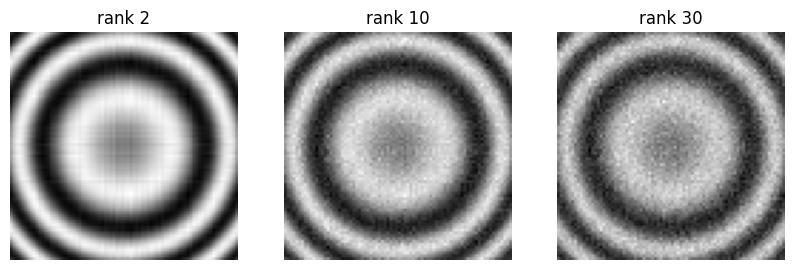

In [3]:
# synthetic image: smooth pattern plus noise
x = np.linspace(-3,3,80)
Xg,Yg = np.meshgrid(x,x)
image = np.sin(Xg**2 + Yg**2) + .2*np.random.randn(80,80)
U,s,Vt = np.linalg.svd(image, full_matrices=False)
fig, ax = plt.subplots(1,3,figsize=(10,3))
for a,k in zip(ax,[2,10,30]):
    recon = U[:,:k] @ np.diag(s[:k]) @ Vt[:k,:]
    a.imshow(recon,cmap='gray'); a.set_title(f'rank {k}'); a.axis('off')
plt.show()

### Output Interpretation

Low-rank reconstructions retain large-scale structure while discarding weaker components. Increasing rank improves detail but may also retain more noise.

## Extended Study Notes

The central learning objective is not only to run code, but to connect the numerical result back to the linear algebra idea. In applied data science, vectors and matrices are not abstract objects only; they are the representation layer for observations, features, images, time series, model parameters, transformations, and decompositions.

A professional workflow should always include sanity checks. For example, reconstructed matrices should be compared with the original matrix, orthogonal matrices should be checked with `Q.T @ Q`, inverse computations should be checked against the identity matrix, and least-squares predictions should be inspected through residuals. These checks make the notebook academically stronger and reduce the risk of blindly trusting a black-box function.

## Chapter Summary

This notebook reproduces the core concept of the chapter using original/adapted Python examples. The code is intentionally compact but runnable, and the surrounding explanation focuses on conceptual understanding, interpretation, and practical relevance for data science.

## Key Takeaways

- Linear algebra concepts become clearer when formulas, geometry, and code are studied together.
- NumPy provides efficient implementations, but understanding the underlying math helps prevent misuse.
- Shape, rank, orientation, and numerical stability are recurring concerns in applied linear algebra.
- Every output should be interpreted as evidence of a mathematical property, not merely as a printed result.